# Demonstration of Segmenting Pipeline

### Setup

In [1]:
# Set Up
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

### Load and preprocess image

In [25]:
# Put Image Path Here:
IMAGE_PATH = r"C:\Users\User\Desktop\RKD\Usecases\Van Haecht\RKD Research Het mystieke huwelijk van de heilige Catharina, ca. 1630.jpg"

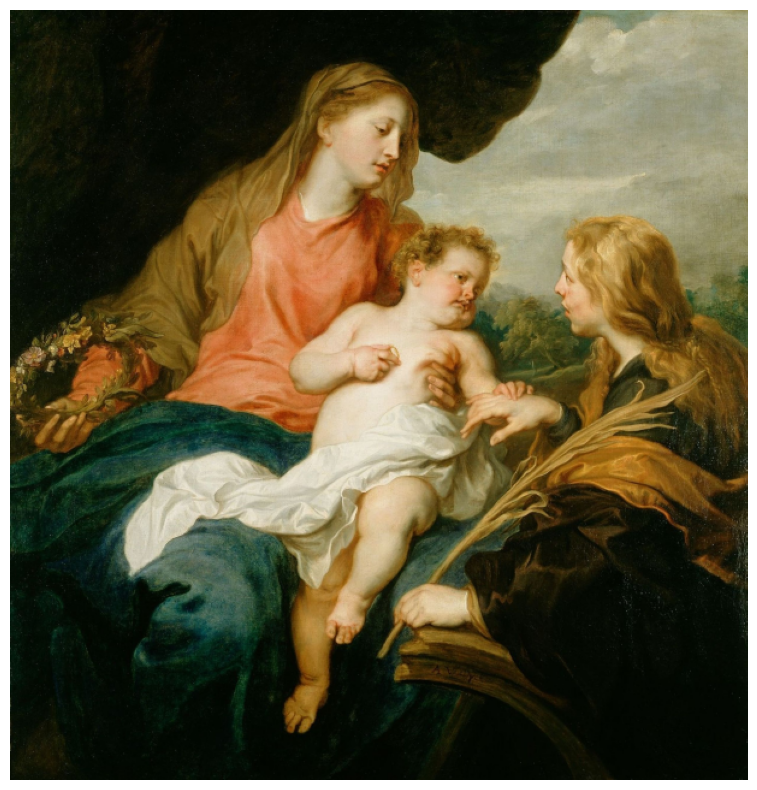

In [26]:
image = cv2.imread(IMAGE_PATH)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

max_dim = 640
scale = max_dim / max(image.shape[:2])
if scale < 1:
    new_size = (int(image.shape[1] * scale), int(image.shape[0] * scale))
    image = cv2.resize(image, new_size, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('off')
plt.show()

#### Use segmenting model to detect and generate masks of subjects

In [18]:
# Can also use Meta's SAM or other segmentation models, but YOLO is more efficient for our purposes
from ultralytics import YOLO
yolo = YOLO("yolo26x-seg.pt")

In [29]:
results = yolo.predict(image, conf=0.3, classes = [0])
print(f"Detected {len(results[0].boxes)} people")


0: 640x640 3 persons, 300.6ms
Speed: 4.1ms preprocess, 300.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Detected 3 people


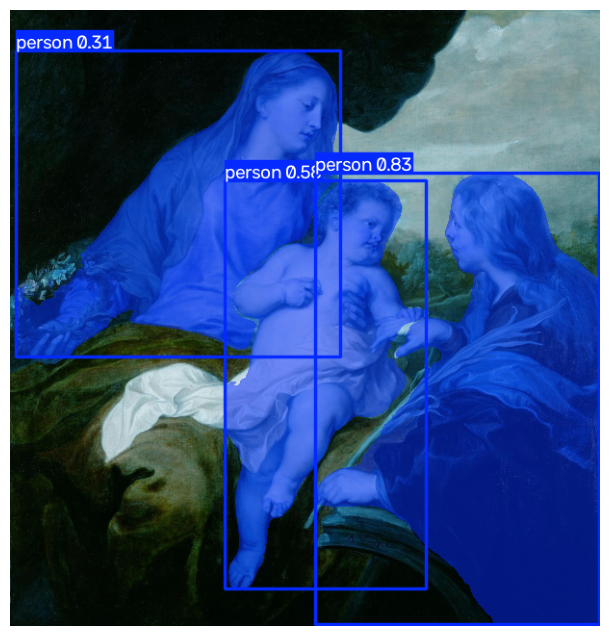

In [30]:
# Visualization of Masks
rendered_image = results[0].plot(boxes=True, labels=True, masks=True)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(rendered_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Load Embedding Logic

In [36]:
import numpy as np
import torch
from transformers import AutoModel, AutoProcessor

MAX_SIDE = 1024

# load the model and processor
MODEL_ID = "google/siglip2-base-patch16-224"
device = 'cuda' if torch.cuda.is_available() else "cpu"

model = AutoModel.from_pretrained(MODEL_ID).to(device)
processor = AutoProcessor.from_pretrained(MODEL_ID)

def l2_normalize(x: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(x, axis=-1, keepdims=True)
    norms[norms == 0] = 1.0
    return (x / norms).astype('float32')


@torch.no_grad()
def embed_image(path: str):
    """
    Given an image path an image is loaded, preprocessed,
    and embedded using a locally run siglip2 model
    """
    # Load Image from Path
    try:
        image = Image.open(path)
    except OSError as e:
        raise FileNotFoundError(f"Invalid image path: {path}") from e

    # Convert to RGB and downscale if necessary
    image = image.convert("RGB")
    if max(image.size) > MAX_SIDE:
        image.thumbnail((MAX_SIDE, MAX_SIDE), Image.LANCZOS)

    inputs = processor(image, return_tensors="pt").to(device)
    feats = model.get_image_features(**inputs).pooler_output
    vector = feats.cpu().numpy()

    # Normalize vector for dot-product search later on
    return l2_normalize(vector)

Loading weights: 100%|██████████| 408/408 [00:00<00:00, 2658.19it/s]


### Connect to QDrantCluster

In [37]:
from qdrant_client import QdrantClient, models
from dotenv import load_dotenv

# See .env.example for url/api_key structure
load_dotenv()

client = QdrantClient(
    url=os.environ["QDRANT_URL"],
    api_key=os.environ["QDRANT_API_KEY"],
    cloud_inference = False
)

### Save, embed, and upload each mask

In [38]:
import random
from qdrant_client.models import PointStruct
from PIL import Image

# Save each mask as its own cropped PNG with a transparent background.
OUT_DIR = r"C:\Users\User\Desktop\Code\rkd\RKD VIsual Search\segment_search\segments"

def save_mask(file_name, mask, dest, source):
    """Given a file_name and mask, saves a crop of source to a destination"""
    h, w = source.shape[:2]

    # masks can come back at model resolution; align to the source image
    if mask.shape != (h, w):
        mask = cv2.resize(mask.astype(np.uint8), (w, h),
                          interpolation=cv2.INTER_NEAREST).astype(bool)

    ys, xs = np.nonzero(mask)
    if len(xs) == 0:
        return None
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1

    crop = source[y0:y1, x0:x1]
    alpha = (mask[y0:y1, x0:x1] * 255).astype(np.uint8)
    rgba = np.dstack([crop, alpha])

    out_path = os.path.join(dest, file_name)
    cv2.imwrite(out_path, cv2.cvtColor(rgba, cv2.COLOR_RGBA2BGRA))

    return out_path


r = results[0]
if r.masks is not None:
    masks = r.masks.data.cpu().numpy().astype(bool)   # (N, H, W) plain bool array
else:
    masks = np.zeros((0, *image.shape[:2]), dtype=bool)

my_points = []

# Can replace with your desired naming convention
from pathlib import Path
file_name = (Path(IMAGE_PATH).stem)

saved = 0
for i, mask in enumerate(masks):
    out_path = save_mask(f"{file_name}_segment{i:03d}.png", mask, OUT_DIR, image)

    if out_path is None:
        continue

    saved += 1

    point = PointStruct(
                id = random.randint(0, 9999),
                vector = {"SIGLIP": embed_image(out_path)[0]},
                payload = {"Origin": file_name,
                           "segment" : i})
    my_points.append(point)

print(f"Saved {saved} masked image(s) to {OUT_DIR}")

Saved 12 masked image(s) to C:\Users\User\Desktop\Code\rkd\RKD VIsual Search\segment_search\segments


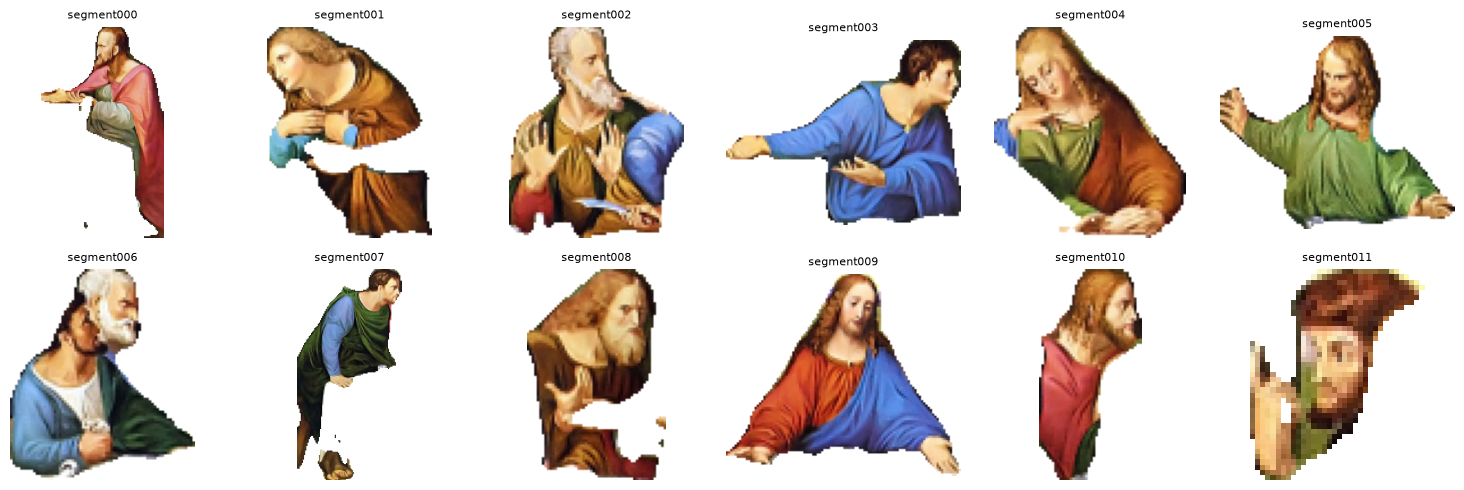

In [58]:
import math

segment_paths = sorted(Path(OUT_DIR).glob(f"{file_name}_segment*.png"))

n = len(segment_paths)
cols = min(6, n) if n else 1
rows = math.ceil(n / cols) if n else 1

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
axes = np.array(axes).reshape(-1)

for ax, path in zip(axes, segment_paths):
    seg = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    seg = cv2.cvtColor(seg, cv2.COLOR_BGRA2RGBA)
    ax.imshow(seg)
    ax.set_title(path.stem.split("_")[-1], fontsize=8)
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Upload each segment as a point to QDrant

client.upload_points(collection_name = "Segments",
                     points = my_points)
print('uploaded!')

uploaded!


### Similarity search against segment database

### Load, crop, and embed query

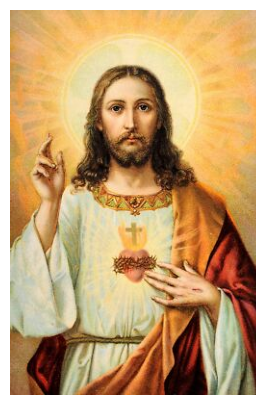

In [40]:
# Put Query Image Path Here:
QUERY_PATH = "images/jesus.jpg"

query = cv2.imread(QUERY_PATH)
query = cv2.cvtColor(query, cv2.COLOR_BGR2RGB)

max_dim = 640
scale = max_dim / max(query.shape[:2])
if scale < 1:
    new_size = (int(query.shape[1] * scale), int(query.shape[0] * scale))
    query = cv2.resize(query, new_size, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(5,5))
plt.imshow(query)
plt.axis('off')
plt.show()


0: 640x416 1 person, 751.7ms
Speed: 4.1ms preprocess, 751.7ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 416)


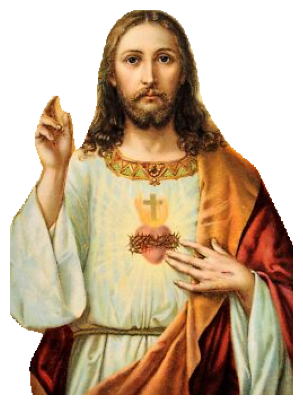

In [54]:
query_results = yolo.predict(query, conf=0.3, classes = [0])

q_r = query_results[0]
if q_r.masks is not None:
    query_masks = q_r.masks.data.cpu().numpy().astype(bool)   # (N, H, W) plain bool array
else:
    query_masks = np.zeros((0, *query.shape[:2]), dtype=bool)

query_mask_path = save_mask(
    f"{Path(QUERY_PATH).stem}_mask.png",
    query_masks[0],
    OUT_DIR,
    query)

query_vec = embed_image(query_mask_path)[0]

# Cropped subject using same YOLO model
query_masked = cv2.imread(query_mask_path, cv2.IMREAD_UNCHANGED)
query_masked = cv2.cvtColor(query_masked, cv2.COLOR_BGRA2RGBA)

plt.figure(figsize=(5,5))
plt.imshow(query_masked)
plt.axis('off')
plt.show()

In [56]:
nn_search_results = client.query_points(
    collection_name = "Segments",
    query = query_vec,
    using = "SIGLIP"
)

Best match: C:\Users\User\Desktop\Code\rkd\RKD VIsual Search\segment_search\segments\last_supper_segment009.png (score=0.7704)


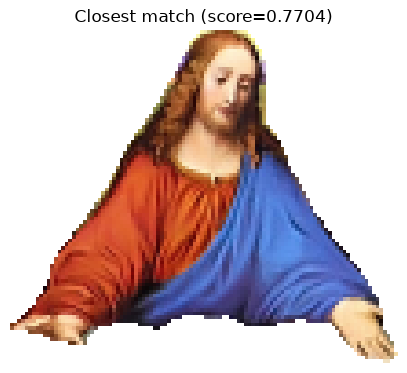

In [ ]:
# Use nearest neighbor search against the segments indexed on qdrant
best = nn_search_results.points[0]
best_path = os.path.join(OUT_DIR, f"{best.payload['Origin']}_segment{best.payload['segment']:03d}.png")

best_match = cv2.imread(best_path, cv2.IMREAD_UNCHANGED)
best_match = cv2.cvtColor(best_match, cv2.COLOR_BGRA2RGBA)

print(f"Best match: {best_path} (score={best.score:.4f})")

plt.figure(figsize=(5, 5))
plt.imshow(best_match)
plt.axis('off')
plt.title(f"Closest match (score={best.score:.4f})")
plt.show()